In [1]:
dataset = "weather"
metric = "kappa"
path = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/NN4SML/performance/dyncpnn"

confs_dict = {
    "air_quality": range(1,51),
    "weather": range(1,51),
    "energy": range(1,51),
    "sine_rw10_mode5": range(1,51),
    "air_quality_future": list(range(1,13)) + list(range(18,30)) + list(range(49,51)),
    "weather_future": list(range(1,46)),
    "energy_future": list(range(1,10)) + list(range(18,51)),
}

confs = confs_dict[dataset]

future = "" if "future" not in path else "_future"
dataset = f"{dataset}{future}"

In [2]:
import os
import pickle
import pandas as pd
import numpy as np

In [3]:
os.chdir(os.path.dirname(os.getcwd()))
os.chdir(os.path.dirname(os.getcwd()))

from evaluation.default_parameters import *

In [4]:
seq_len = set_seq_len(dataset)
batch_size = set_batch_size(dataset)

n_tasks = 5 if "energy" in dataset else 8

metrics = []
memory = []
cl_metrics = []
task_perf = {}

for conf in confs:
    print(conf, end="\r")
    # with open(os.path.join(path, f"{dataset}_{conf}conf", f"checkpoint_128_{seq_len}.pkl"), "rb") as f:
    #     check = pickle.load(f)

    with open(os.path.join(path, "exec", f"{dataset}_{conf}conf", f"metric_tables_{batch_size}_{seq_len}.pkl"), "rb") as f:
        perf = pickle.load(f)

    with open(os.path.join(path, "exec", f"{dataset}_{conf}conf", f"cl_metrics_{batch_size}_{seq_len}.pkl"), "rb") as f:
        cl = pickle.load(f)

    for model in sorted(list(perf.keys())):
        if "_feat" in model.lower():
            continue
        if model not in task_perf:
            task_perf[model] = []
        task_perf[model].append(perf[model][metric][0])
        df = pd.DataFrame(perf[model][metric][0])
        df.columns = [f"test{t}" for t in range(1,n_tasks+1)]
        df["train"] = [t for t in range(1,n_tasks+1)]
        df["model"] = model
        df["conf"] = conf
        metrics.append(df)
        
        df = pd.DataFrame([perf[model]["memory"][0]])
        df.columns = [f"task{t}" for t in range(1,n_tasks+1)]
        df["model"] = model
        df["conf"] = conf
        memory.append(df)
        
        df = pd.DataFrame.from_dict({k: [cl[model][metric][0][k]] for k in cl[model][metric][0]})
        df["model"] = model
        df["conf"] = conf
        cl_metrics.append(df)
metrics = pd.concat(metrics)
metrics.round(3).to_excel(os.path.join(path, f"cl_table_{metric}_{dataset}.xlsx"), index=False)
metrics.to_csv(os.path.join(path, f"cl_table_{metric}_{dataset}.csv"), index=False)
with open(os.path.join(path, f"task_perf_{metric}_{dataset}.pkl"), "wb") as f:
    pickle.dump(task_perf, f)
task_perf_avg = task_perf.copy()
for model in task_perf_avg:
    task_perf_avg[model] = np.array(task_perf[model]).mean(axis=0)
with open(os.path.join(path, f"task_perf_avg_{metric}_{dataset}.pkl"), "wb") as f:
    pickle.dump(task_perf_avg, f)
memory = pd.concat(memory)
memory.round(3).to_excel(os.path.join(path, f"memory_{dataset}.xlsx"), index=False)
cl_metrics = pd.concat(cl_metrics)
cl_metrics = cl_metrics.sort_values(["model", "conf"])
cl_metrics.round(3).to_excel(os.path.join(path, f"cl_{metric}_{dataset}.xlsx"), index=False)
cl_metrics.to_csv(os.path.join(path, f"cl_{metric}_{dataset}.csv"), index=False)

In [5]:
cl_metrics_avg = cl_metrics.groupby("model").agg(["mean", "std"]).reset_index().drop(columns=["conf"])
cl_metrics_avg.columns = ['_'.join(col).strip() for col in cl_metrics_avg.columns.values]
cl_metrics_avg['model_lower'] = cl_metrics_avg["model_"].apply(lambda x: x.lower())
cl_metrics_avg = cl_metrics_avg.sort_values('model_lower').drop(columns='model_lower')
cl_metrics_avg.round(3).drop(columns=[c for c in cl_metrics_avg.columns if "std" in c]).to_excel(os.path.join(path, f"cl_avg_{metric}_{dataset}.xlsx"), index=False)

/var/folders/8b/bn5g5hn14bv56xr733msk9tr0000gn/T/ipykernel_19590/3033191944.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  cl_metrics_avg = cl_metrics.groupby("model").agg(["mean", "std"]).reset_index().drop(columns=["conf"])


In [6]:
def format_values(x, p):
    mean = "{:.2f}".format(x[f"{p}_mean"]).replace("0.",".")
    std = "{:.2f}".format(x[f"{p}_std"]).replace("0.",".")
    return f"{mean} \u00B1 {std}"

In [7]:
cl_table = cl_metrics_avg.copy()

for p in ["average", "a_metric", "bwt"]:
    cl_table[p] = cl_table.apply(
        lambda x : format_values(x, p),
        axis=1
    )

cl_table = cl_table.drop(columns=[c for c in cl_table.columns if "_mean" in c or "_std" in c]).rename(columns={"model_":"model"})
cl_table.to_excel(os.path.join(path, f"cl_table_{metric}_{dataset}.xlsx"), index=False)
cl_table

,model,average,a_metric,bwt
0,ARF,.03 ± .05,.04 ± .02,-.18 ± .04
1,ARF_TA,.22 ± .16,.20 ± .05,-.24 ± .06
3,cLSTM,.04 ± .08,.11 ± .02,-.69 ± .06
4,cPNN,.48 ± .06,.47 ± .07,-.07 ± .07
2,DyncPNN,.54 ± .07,.55 ± .07,-.11 ± .08


In [8]:
models = list(cl_table["model"].unique())
models = sorted([m for m in models if "_feat" not in m])

In [9]:
from tests import dependentTest

In [10]:
results = {}
for p in ["average", "a_metric", "bwt"]:
    results[p] = {}
    results[p]["models"] = {}
    for m1 in models:
        results[p]["models"][m1] = []
        for m2 in models:
            if m1==m2:
                continue
            test_result = dependentTest(list(cl_metrics[cl_metrics["model"]==m1][p]), list(cl_metrics[cl_metrics["model"]==m2][p]))
            if test_result["result"]:
                 results[p]["models"][m1].append(m2)
        if len(results[p]["models"][m1]) == len(models)-1:
            results[p]["best"] = m1
            
results

{'average': {'models': {'ARF': [],
   'ARF_TA': ['ARF', 'cLSTM'],
   'DyncPNN': ['ARF', 'ARF_TA', 'cLSTM', 'cPNN'],
   'cLSTM': [],
   'cPNN': ['ARF', 'ARF_TA', 'cLSTM']},
  'best': 'DyncPNN'},
 'a_metric': {'models': {'ARF': [],
   'ARF_TA': ['ARF', 'cLSTM'],
   'DyncPNN': ['ARF', 'ARF_TA', 'cLSTM', 'cPNN'],
   'cLSTM': ['ARF'],
   'cPNN': ['ARF', 'ARF_TA', 'cLSTM']},
  'best': 'DyncPNN'},
 'bwt': {'models': {'ARF': ['ARF_TA', 'cLSTM'],
   'ARF_TA': ['cLSTM'],
   'DyncPNN': ['ARF', 'ARF_TA', 'cLSTM'],
   'cLSTM': [],
   'cPNN': ['ARF', 'ARF_TA', 'DyncPNN', 'cLSTM']},
  'best': 'cPNN'}}

In [11]:
import json

with open(os.path.join(path, f"cl_table_{metric}_{dataset}_test.json"), 'w') as file:
    json.dump(results, file, indent=4)

In [12]:
memory_avg = memory.groupby("model").mean().reset_index().drop(columns=["conf"]).sort_values(f"task{n_tasks}")
memory_avg = memory_avg[memory_avg["model"].apply(lambda x: "arf" not in x.lower())]
memory_avg.round(3).to_excel(os.path.join(path, f"memory_avg_{dataset}.xlsx"), index=False)
memory_avg.round(3)

,model,task1,task2,task3,task4,task5,task6,task7,task8
3,cLSTM,0.047,0.047,0.047,0.047,0.047,0.047,0.047,0.047
2,DyncPNN,0.047,0.135,0.232,0.352,0.479,0.616,0.584,0.654
4,cPNN,0.146,0.280,0.421,0.555,0.708,0.898,1.056,1.242


In [13]:
memory_avg

,model,task1,task2,task3,task4,task5,task6,task7,task8
3,cLSTM,0.047319,0.047319,0.047319,0.047319,0.047319,0.047319,0.047319,0.047319
2,DyncPNN,0.047319,0.135025,0.231888,0.351628,0.479126,0.616261,0.583893,0.654444
4,cPNN,0.146254,0.279959,0.420799,0.554766,0.707896,0.897623,1.056028,1.242240


In [14]:
from plot_utils import *
import matplotlib.pyplot as plt

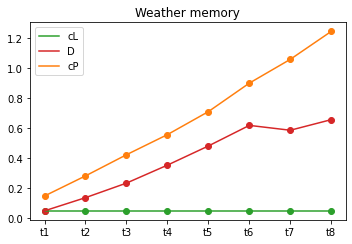

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 3.5))
for _, r in memory_avg.iterrows():
    m = model_name(r["model"])
    values = r[[f"task{t}" for t in range(1,n_tasks+1)]].values
    ax.plot(values, label=m, color=colors[m])
    ax.scatter(x=np.arange(0,n_tasks), y=values, color=colors[m])
ax.set_xticks(np.arange(0,n_tasks))
ax.set_xticklabels([f"t{i}" for i in range(1,n_tasks+1)])
ax.legend()
ax.set_title(f"{dataset.replace('_', ' ').title().replace(' ','')} memory")
plt.tight_layout()
plt.savefig(os.path.join(path, f"memory_{dataset}.png"), dpi=300)